# 02 — Data Cleaning & Validation
**Day 2.** Goal: turn the raw SCADA table into a validated, quality-checked, feature-ready
table in `data/interim/`, joined against the power curve and alarm history.

**What Day 1's exploration told us (worth restating before cleaning):**
- SCADA (Dataset-6) covers **one turbine only — `WTG_001`**, full year 2025, 10-minute resolution, 52,560 rows, no nulls, no duplicate timestamps.
- Alarms and Maintenance cover **50 turbines** (`WTG_001`–`WTG_050`) across **2023–2025** — they *do* overlap SCADA's 2025 range for `WTG_001` (≈997 alarm events, ≈182 maintenance records that year).
- Grid/Curtailment (Dataset-9) only covers **Jan–Mar 2024** — it does **not** overlap SCADA's 2025 data at all. We can't merge it onto SCADA directly; note it as a known gap, usable later for a separate curtailment-loss analysis.
- Layout dataset (Dataset-11A) uses a different turbine ID scheme (`T001`...) and different turbine model names (`WTG-6.0MW`) than SCADA/alarms/maintenance (`WTG_001`, `WTG_2500_110`). **These are not the same farm** — don't join layout data onto SCADA.
- SCADA's `active_power_kw` maxes out at exactly 2500 kW, matching the `WTG_2500_110` power curve in Dataset-5. That's our turbine model for the forecasting work.

This notebook only works with what's real: **SCADA + Power Curve + Alarms (WTG_001, 2025)**.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_loader import load_config, raw_path, interim_path
from src.data.loaders import load_scada, load_power_curve, load_alarms
from src.data import validation as dq

cfg = load_config()


## 1. Load raw SCADA and run the validation-rule summary
Uses `src/data/validation.py`, which implements the exact rules from the technical report, Section 17.

In [2]:
scada = load_scada(cfg)
print("Shape:", scada.shape)
print("Turbines:", scada['turbine_id'].unique())

rated_power_kw = cfg["turbine_defaults"]["rated_power_kw"]  # 3000 in config default -- we'll confirm the real value below
print("Actual max active_power_kw in data:", scada["active_power_kw"].max())


Shape: (52560, 32)
Turbines: ['WTG_001']
Actual max active_power_kw in data: 2500.0


The config's default `rated_power_kw` (3000) doesn't match this turbine. Fix that here rather than
silently using the wrong rated capacity in the validation check -- this is exactly the kind of
assumption error the report warns about.

In [3]:
rated_power_kw = 2500  # WTG_2500_110, confirmed from Dataset-5 and SCADA max

summary = dq.run_all_checks(scada, rated_power_kw=rated_power_kw)
summary


,check,failing_rows
0,negative_wind_speed,0
1,wind_direction_out_of_range,0
2,power_exceeds_rated_capacity,0
3,rotor_stationary_but_generating,0
4,duplicate_timestamp_rows,0
5,missing_values_total,0


## 2. Confirm timestamp continuity
A 10-minute series for one full year should have exactly 52,560 rows with no gaps. Confirm that, since a silent gap would bias any model trained on this later.

In [4]:
full_index = pd.date_range(scada["timestamp"].min(), scada["timestamp"].max(), freq="10min")
missing_timestamps = full_index.difference(scada["timestamp"])
print(f"Expected rows: {len(full_index)}, Actual rows: {len(scada)}, Missing timestamps: {len(missing_timestamps)}")

if len(missing_timestamps) > 0:
    print(missing_timestamps[:10])


Expected rows: 52560, Actual rows: 52560, Missing timestamps: 0


## 3. Merge in expected power from the turbine power curve
This is the Report's central idea in Section 16: `Expected Power − Actual Power = Energy Loss`.
We interpolate the power curve (0.5 m/s bins) onto SCADA's exact wind speeds.

In [5]:
power_curve = load_power_curve(cfg)
curve = power_curve[power_curve["turbine_model"] == "WTG_2500_110"].sort_values("wind_speed_mps")

scada["expected_power_kw"] = np.interp(
    scada["wind_speed_mps"], curve["wind_speed_mps"], curve["expected_power_kw"]
)
scada["power_loss_kw"] = scada["expected_power_kw"] - scada["active_power_kw"]

scada[["wind_speed_mps", "active_power_kw", "expected_power_kw", "power_loss_kw"]].describe()


,wind_speed_mps,active_power_kw,expected_power_kw,power_loss_kw
count,52560.000000,52560.000000,52560.000000,52560.000000
mean,7.500598,746.076103,844.149768,98.073665
std,2.378207,633.858735,691.540650,107.344126
min,0.000000,0.000000,0.000000,-0.190000
25%,5.870000,251.847500,294.694000,31.507500
50%,7.490000,572.060000,658.160000,73.406000
75%,9.140000,1075.670000,1234.944000,137.591000
max,17.400000,2500.000000,2500.000000,2473.860000


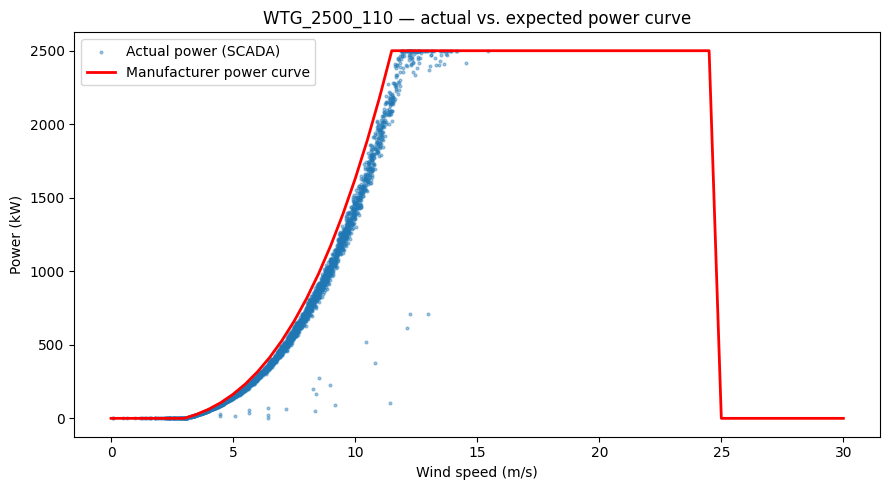

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
sample = scada.sample(3000, random_state=42).sort_values("wind_speed_mps")
ax.scatter(sample["wind_speed_mps"], sample["active_power_kw"], s=4, alpha=0.4, label="Actual power (SCADA)")
ax.plot(curve["wind_speed_mps"], curve["expected_power_kw"], color="red", linewidth=2, label="Manufacturer power curve")
ax.set_xlabel("Wind speed (m/s)")
ax.set_ylabel("Power (kW)")
ax.set_title("WTG_2500_110 — actual vs. expected power curve")
ax.legend()
fig.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/day2_power_curve_check.png", dpi=150)
plt.show()


## 4. Merge alarm windows onto SCADA
For each SCADA row, flag whether the turbine had an active alarm at that timestamp. Uses
`merge_asof` (backward) plus an end-time check rather than a slow row-by-row interval scan —
important once you're doing this over 50 turbines × several years later, not just one.

In [7]:
alarms = load_alarms(cfg)
a1 = alarms[alarms["turbine_id"] == "WTG_001"].copy()
a1["event_end_timestamp"] = a1["event_end_timestamp"].fillna(a1["event_timestamp"])
a1 = a1.sort_values("event_timestamp")

scada = scada.sort_values("timestamp").reset_index(drop=True)
scada = pd.merge_asof(
    scada,
    a1[["event_timestamp", "event_end_timestamp", "alarm_category", "severity", "component"]],
    left_on="timestamp", right_on="event_timestamp", direction="backward"
)

# only keep the alarm columns where the SCADA timestamp actually falls inside the alarm window
active_alarm = (scada["timestamp"] >= scada["event_timestamp"]) & (scada["timestamp"] <= scada["event_end_timestamp"])
scada["active_alarm"] = active_alarm.fillna(False)
scada.loc[~scada["active_alarm"], ["alarm_category", "severity", "component"]] = None
scada = scada.drop(columns=["event_timestamp", "event_end_timestamp"])

print(f"Rows with an active alarm: {scada['active_alarm'].sum():,} / {len(scada):,} ({scada['active_alarm'].mean():.1%})")
scada[scada["active_alarm"]][["timestamp", "alarm_category", "severity", "component", "power_loss_kw"]].head()


Rows with an active alarm: 29,204 / 52,560 (55.6%)


,timestamp,alarm_category,severity,component,power_loss_kw
10,2025-01-01 01:40:00,Temperature,High,Gearbox,167.770
11,2025-01-01 01:50:00,Temperature,High,Gearbox,237.382
12,2025-01-01 02:00:00,Temperature,High,Gearbox,143.968
13,2025-01-01 02:10:00,Temperature,High,Gearbox,397.210
14,2025-01-01 02:20:00,Temperature,High,Gearbox,191.718


## 5. Check: does power loss actually spike during alarms?
A quick sanity check before trusting this merged table for Day 3 modeling — if alarm periods
don't show materially higher power loss, something is misaligned.

In [8]:
comparison = scada.groupby("active_alarm")["power_loss_kw"].agg(["mean", "median", "count"])
comparison


,mean,median,count
active_alarm,,,
False,99.225731,74.640,23356
True,97.152297,72.528,29204


## 6. Final cleaning pass and save to `data/interim/`
Apply the rule-based fixes: drop exact duplicate rows (none expected here, but keep the code for
when you scale to 50 turbines), clip any physically impossible values, and save.

In [9]:
before = len(scada)
scada = scada.drop_duplicates(subset=["timestamp", "turbine_id"], keep="first")
scada = scada[scada["wind_speed_mps"] >= 0]
scada = scada[scada["wind_direction_deg"].between(0, 360)]
scada = scada[scada["active_power_kw"] <= rated_power_kw]
after = len(scada)
print(f"Rows before cleaning: {before}, after: {after}, dropped: {before - after}")


Rows before cleaning: 52560, after: 52560, dropped: 0


In [10]:
out_path = interim_path("scada_wtg001_cleaned_2025.csv", cfg)
out_path.parent.mkdir(parents=True, exist_ok=True)
scada.to_csv(out_path, index=False)
print("Saved:", out_path)
print("Final shape:", scada.shape)
scada.head()


Saved: C:\Users\ashok\Downloads\wind-energy-ai-platform\wind-energy-ai-platform\data\interim\scada_wtg001_cleaned_2025.csv
Final shape: (52560, 38)


,timestamp,wind_farm_id,turbine_id,wind_speed_mps,wind_direction_deg,wind_gust_mps,active_power_kw,reactive_power_kvar,energy_generated_kwh,rotor_speed_rpm,...,availability_status,operating_status,curtailment_status,alarm_code,expected_power_kw,power_loss_kw,alarm_category,severity,component,active_alarm
0,2025-01-01 00:00:00,WF_IND_001,WTG_001,8.05,241.2,9.51,699.30,56.04,116.55,10.79,...,Available,Generating,Not Curtailed,NONE,828.700,129.400,None,None,None,False
1,2025-01-01 00:10:00,WF_IND_001,WTG_001,5.71,208.9,7.39,233.11,39.68,38.85,9.54,...,Available,Generating,Not Curtailed,NONE,268.102,34.992,None,None,None,False
2,2025-01-01 00:20:00,WF_IND_001,WTG_001,9.01,228.0,10.85,1013.01,43.42,168.83,11.53,...,Available,Generating,Not Curtailed,NONE,1179.096,166.086,None,None,None,False
3,2025-01-01 00:30:00,WF_IND_001,WTG_001,9.43,245.9,10.74,1274.91,32.53,212.49,11.90,...,Available,Generating,Not Curtailed,NONE,1359.528,84.618,None,None,None,False
4,2025-01-01 00:40:00,WF_IND_001,WTG_001,4.30,252.5,6.46,77.36,80.63,12.89,8.34,...,Available,Generating,Not Curtailed,NONE,89.140,11.780,None,None,None,False


---
## Day 2 checkpoint

- `data/interim/scada_wtg001_cleaned_2025.csv` now exists: validated SCADA for `WTG_001`, 2025,
  enriched with `expected_power_kw`, `power_loss_kw`, and alarm-window flags.
- Grid/curtailment and layout datasets are confirmed **not mergeable** onto this table (different
  time range / different farm) — treat them as separate analyses later, not blockers.
- The 50-turbine alarm/maintenance history exists but SCADA only gives us telemetry for one of
  those 50 turbines. **Day 3's forecasting model will necessarily be single-turbine** — call this
  out explicitly in the proposal appendix (Day 4's one-pager) so expectations are set correctly.

Next: `03_feature_engineering.ipynb` (Day 3) — time-of-day/seasonality features, rolling
generation averages, chronological train/val/test split, and the first XGBoost/LightGBM
baseline forecasting model.